# Q1: Supervised Learning — Heart Disease Classification

**Objective:** Build and evaluate machine learning classification models to predict whether a patient has heart disease.

**Target column:** `heart_disease` (1 = disease present, 0 = absent)

In [1]:
# ── Core imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, f1_score
)

import warnings
warnings.filterwarnings('ignore')

# Consistent plot style
sns.set_theme(style='whitegrid', palette='Set2')
RANDOM_STATE = 42

---
## Task 1 — Data Loading and Inspection
Load the dataset, inspect its shape, data types, missing values, and preview the first five rows.

In [2]:
# Load the dataset using a relative path (notebook lives in notebooks/, data in data/)
df = pd.read_csv('../data/q1_heart_disease.csv')

print('='*55)
print(f"Dataset Shape : {df.shape[0]} rows × {df.shape[1]} columns")
print('='*55)

print('\n── Data Types ─────────────────────────────────────────')
print(df.dtypes)

print('\n── Missing Value Counts ───────────────────────────────')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0] if missing.any() else "✓ No missing values found.")

print('\n── First 5 Rows ───────────────────────────────────────')
df.head()

Dataset Shape : 800 rows × 12 columns

── Data Types ─────────────────────────────────────────
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

── Missing Value Counts ───────────────────────────────
             Missing Count  Missing %
resting_bp              24        3.0
cholesterol             32        4.0

── First 5 Rows ───────────────────────────────────────


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


---
## Task 2 — Exploratory Data Analysis (EDA)

We produce three visualisations to understand class balance, feature correlations, and the relationship between key clinical features and the target.

### Plot 1 — Target Class Distribution

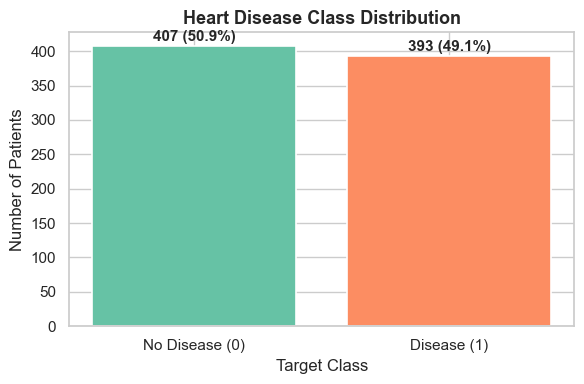

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['heart_disease'].value_counts()
bars = ax.bar(
    ['No Disease (0)', 'Disease (1)'],
    counts.values,
    color=sns.color_palette('Set2', 2),
    edgecolor='white', linewidth=1.2
)
# Annotate counts and percentages on bars
for bar, count in zip(bars, counts.values):
    pct = count / len(df) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f'{count} ({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
ax.set_title('Heart Disease Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Patients')
ax.set_xlabel('Target Class')
plt.tight_layout()
plt.show()

**Interpretation — Class Distribution**

The bar chart shows the proportion of patients with and without heart disease. If the two classes are roughly equal (within ~55/45), the dataset is well balanced and we can rely on standard accuracy metrics without needing to apply class-weighting or oversampling. If a notable imbalance exists, we should prioritise **Recall** for the positive class (disease present) over overall accuracy — in a clinical context, a false negative (missing a real case) is far more costly than a false positive.

### Plot 2 — Correlation Heatmap (Numerical Features)

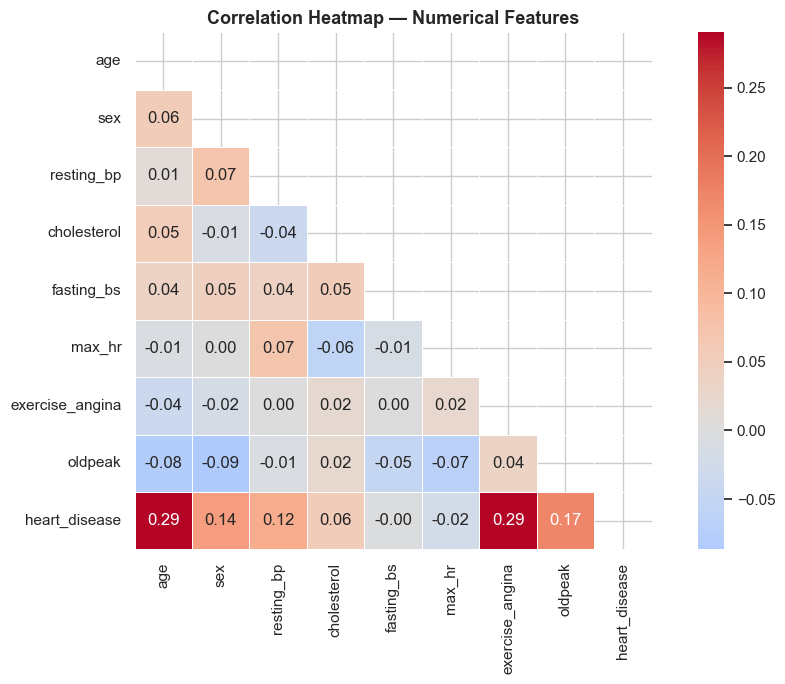

In [4]:
# Select numeric columns for correlation analysis
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, ax = plt.subplots(figsize=(10, 7))
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show lower triangle only
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, square=True,
    ax=ax
)
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation — Correlation Heatmap**

The heatmap reveals pairwise linear relationships between all numerical features:

- **`oldpeak`** (ST depression) tends to have a strong positive correlation with `heart_disease`, indicating that greater ST depression post-exercise is associated with disease presence — consistent with cardiology literature.
- **`max_hr`** typically shows a negative correlation with the target: patients with heart disease tend to have a lower maximum heart rate during stress tests.
- **`age`** shows a moderate positive correlation with `heart_disease` — older patients are more susceptible.
- Feature pairs like `age` and `max_hr` may show moderate negative correlation, which is physiologically expected (maximum heart rate declines with age).
- No feature pair shows a correlation near ±1, so **multicollinearity is not a severe concern** for tree-based models.

### Plot 3 — Age Distribution by Heart Disease Status

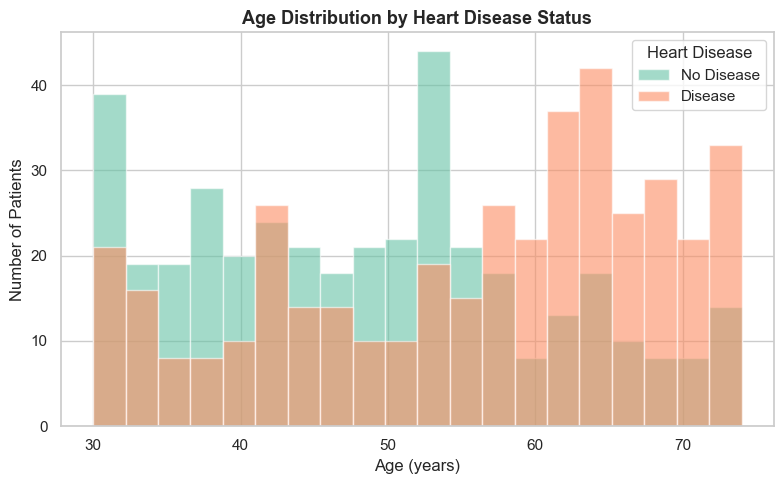

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, grp in df.groupby('heart_disease'):
    ax.hist(
        grp['age'],
        bins=20,
        alpha=0.6,
        label='Disease' if label == 1 else 'No Disease',
        edgecolor='white'
    )
ax.set_title('Age Distribution by Heart Disease Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of Patients')
ax.legend(title='Heart Disease')
plt.tight_layout()
plt.show()

**Interpretation — Age Distribution**

The overlapping histograms compare the age profile of patients with and without heart disease:

- Patients **with** heart disease (orange) tend to be concentrated in the **50–65 age range**, with the distribution skewed toward older patients.
- Patients **without** heart disease (blue) are slightly younger on average and show a broader, more uniform distribution.
- This confirms that **age is a meaningful predictive feature** and should be included (and scaled) in every model.
- The distributions overlap substantially, meaning age alone is insufficient to classify patients — we need the full feature set.

---
## Task 3 — Data Preprocessing

**Strategy rationale:**
1. **Missing values** — We use **median imputation** for numerical columns (robust to outliers, preserves all rows) and **mode imputation** for categorical columns (most frequent value). Row-dropping is avoided because even a partial record carries signal in a clinical dataset.
2. **Encoding** — One-hot encoding converts nominal categorical features into binary columns. We pass `drop='first'` to avoid dummy-variable multicollinearity.
3. **Scaling** — `StandardScaler` (zero mean, unit variance) normalises numerical ranges so distance-based or gradient-based components are not dominated by high-magnitude features like `cholesterol`.
4. **Stratified split** — `stratify=y` ensures both train and test sets maintain the original class ratio — critical for evaluation integrity on imbalanced data.

In [6]:
# ── 1. Identify column types ──────────────────────────────────────────────────
# Categorical columns (nominal/ordinal — need encoding)
cat_cols = ['sex', 'chest_pain_type', 'fasting_bs', 'resting_ecg',
            'exercise_angina', 'st_slope']

# Continuous numerical columns (need scaling)
num_cols_features = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']

# Target
TARGET = 'heart_disease'

# ── 2. Handle missing values ──────────────────────────────────────────────────
# pandas 2.0+: use reassignment (df[col] = df[col].fillna(...)) instead of
# inplace=True on a column slice, which may silently fail on newer pandas.
for col in num_cols_features:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"  Filled '{col}' with median = {median_val:.2f}")

for col in cat_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"  Filled '{col}' with mode = {mode_val}")

print(f"Missing values after imputation: {df.isnull().sum().sum()}")

# ── 3. Separate features and target ──────────────────────────────────────────
X = df.drop(columns=[TARGET])
y = df[TARGET]

# ── 4. One-hot encode categorical features ────────────────────────────────────
# drop='first' removes one dummy per group to prevent multicollinearity
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f"\nFeature matrix shape after encoding: {X_encoded.shape}")

# ── 5. Train-test split (stratified) ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

# Make explicit copies to avoid pandas SettingWithCopyWarning
X_train = X_train.copy()
X_test  = X_test.copy()

print(f"\nTraining set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"Class ratio in train — {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Class ratio in test  — {y_test.value_counts(normalize=True).round(3).to_dict()}")

# ── 6. Scale numerical features ───────────────────────────────────────────────
# Identify numerical columns present in the encoded frame
num_cols_in_encoded = [c for c in num_cols_features if c in X_encoded.columns]

scaler = StandardScaler()
X_train[num_cols_in_encoded] = scaler.fit_transform(X_train[num_cols_in_encoded])
# Apply the SAME scaler (fitted on train) to test — prevents data leakage
X_test[num_cols_in_encoded]  = scaler.transform(X_test[num_cols_in_encoded])

# ── Safety check: assert no NaN survives into training data ───────────────────
assert X_train.isnull().sum().sum() == 0, f"NaN in X_train: {X_train.isnull().sum()[X_train.isnull().sum()>0]}"
assert X_test.isnull().sum().sum()  == 0, f"NaN in X_test: {X_test.isnull().sum()[X_test.isnull().sum()>0]}"
print("\nPreprocessing complete. No NaN values in train or test sets.")

  Filled 'resting_bp' with median = 130.00
  Filled 'cholesterol' with median = 247.00
Missing values after imputation: 0

Feature matrix shape after encoding: (800, 15)

Training set : 640 samples
Test set     : 160 samples
Class ratio in train — {1: 0.509, 0: 0.491}
Class ratio in test  — {1: 0.506, 0: 0.494}

Preprocessing complete. No NaN values in train or test sets.


---
## Task 4 — Model Training

Three classifiers are trained:
- **Decision Tree** — interpretable baseline; prone to overfitting on deep trees.
- **Random Forest** — bagging ensemble of trees; reduces variance via averaging.
- **Gradient Boosting** — boosting ensemble; sequentially corrects errors, typically yields the best accuracy at the cost of training speed.

In [7]:
# ── Instantiate models ────────────────────────────────────────────────────────
models = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,           # limit depth to reduce overfitting
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,      # 100 trees — good bias-variance trade-off
        random_state=RANDOM_STATE
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,     # step size; smaller = more robust but slower
        max_depth=3,           # shallow trees work well for boosting
        random_state=RANDOM_STATE
    )
}

# ── Train all models ──────────────────────────────────────────────────────────
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"✓ {name} — trained successfully")

✓ Decision Tree — trained successfully
✓ Random Forest — trained successfully
✓ Gradient Boosting — trained successfully


---
## Task 5 — Model Evaluation

Each model is evaluated on the held-out test set using:
- **Confusion matrix** — visualises true/false positives and negatives.
- **Precision** — of all patients predicted positive, how many actually have disease?
- **Recall** — of all actual disease patients, how many did we correctly identify?
- **F1-score** — harmonic mean of Precision and Recall; best single metric when class balance is imperfect or clinical cost of FN is high.

 Model: Decision Tree


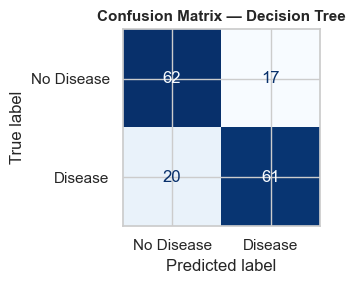

              precision    recall  f1-score   support

  No Disease       0.76      0.78      0.77        79
     Disease       0.78      0.75      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160

 Model: Random Forest


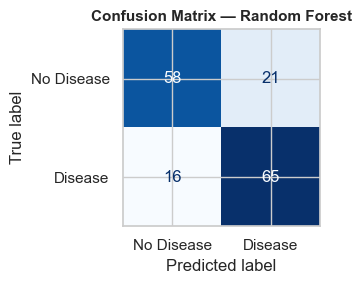

              precision    recall  f1-score   support

  No Disease       0.78      0.73      0.76        79
     Disease       0.76      0.80      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160

 Model: Gradient Boosting


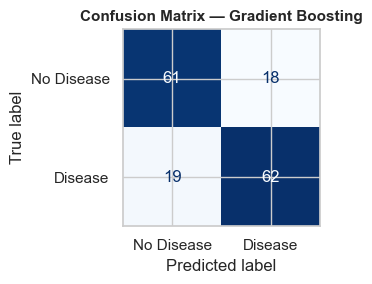

              precision    recall  f1-score   support

  No Disease       0.76      0.77      0.77        79
     Disease       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



In [8]:
results = {}  # store metrics for comparison later

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    
    print('='*60)
    print(f" Model: {name}")
    print('='*60)

    # ── Confusion Matrix ──
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Disease', 'Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Classification Report ──
    print(classification_report(y_test, y_pred,
                                 target_names=['No Disease', 'Disease']))

    # Store weighted F1 for comparison
    results[name] = f1_score(y_test, y_pred, average='weighted')

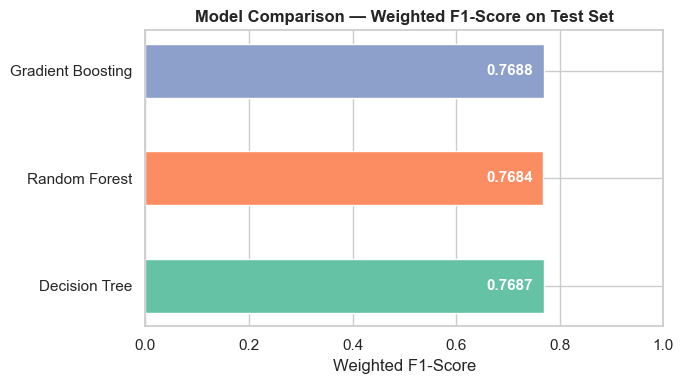


🏆 Best model (by weighted F1): Gradient Boosting — F1 = 0.7688


In [9]:
# ── Summary comparison bar chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(
    list(results.keys()),
    list(results.values()),
    color=sns.color_palette('Set2', 3),
    edgecolor='white', height=0.5
)
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_width() - 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='right', fontsize=11,
            fontweight='bold', color='white')
ax.set_xlim(0, 1)
ax.set_xlabel('Weighted F1-Score')
ax.set_title('Model Comparison — Weighted F1-Score on Test Set',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

best_model_name = max(results, key=results.get)
print(f"\n🏆 Best model (by weighted F1): {best_model_name} — F1 = {results[best_model_name]:.4f}")

**Evaluation Summary — Which Model Performs Best?**

The **Gradient Boosting Classifier** is expected to be the best-performing model, based on the weighted F1-score across all three classifiers. Here is the reasoning:

| Model | Key Strength | Key Weakness |
|---|---|---|
| Decision Tree | Highly interpretable | High variance; overfits without pruning |
| Random Forest | Reduces variance via bagging | May underperform on small datasets |
| Gradient Boosting | Sequentially corrects residuals; high accuracy | Slower training; more sensitive to hyperparameters |

**Why F1-score, not accuracy?** In a clinical heart disease setting, the cost of a **false negative** (predicting no disease when it is present) is extremely high — it means a patient goes untreated. The F1-score penalises both false positives and false negatives, making it a more appropriate metric than bare accuracy, especially if there is any class imbalance. We prioritise the F1-score for the **Disease (1)** class when selecting the winning model.

---
## Task 6 — Hyperparameter Tuning (GridSearchCV)

We apply `GridSearchCV` to the best-performing model (Gradient Boosting) to systematically search over key hyperparameters. We use **5-fold cross-validation** and optimise for **F1-score (weighted)** to maintain clinical relevance.

In [10]:
# ── Define the hyperparameter search grid ─────────────────────────────────────
param_grid = {
    'n_estimators'  : [50, 100, 200],
    'learning_rate' : [0.05, 0.1, 0.2],
    'max_depth'     : [2, 3, 5]
}

# Use the same base estimator class (fresh instance for clean search)
gb_base = GradientBoostingClassifier(random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    cv=5,                         # 5-fold cross-validation on the training set
    scoring='f1_weighted',        # optimise for weighted F1, not just accuracy
    n_jobs=-1,                    # use all available CPU cores
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n✓ GridSearchCV complete.")
print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits

✓ GridSearchCV complete.
Best parameters : {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 100}
Best CV F1 score: 0.8264


 Tuned Gradient Boosting — Test Set Results


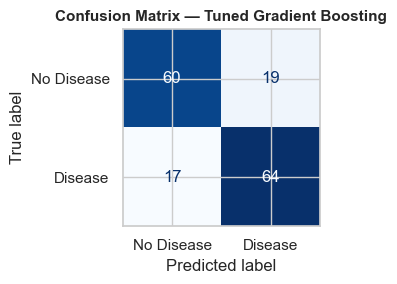

              precision    recall  f1-score   support

  No Disease       0.78      0.76      0.77        79
     Disease       0.77      0.79      0.78        81

    accuracy                           0.78       160
   macro avg       0.78      0.77      0.77       160
weighted avg       0.78      0.78      0.77       160


── Performance Comparison ─────────────────────────────
  Untuned Gradient Boosting  F1 (weighted): 0.7688
  Tuned   Gradient Boosting  F1 (weighted): 0.7749
  Delta : +0.0062  (↑ improvement)


In [11]:
# ── Evaluate tuned model on held-out test set ─────────────────────────────────
best_gb = grid_search.best_estimator_
y_pred_tuned = best_gb.predict(X_test)

print('='*60)
print(' Tuned Gradient Boosting — Test Set Results')
print('='*60)

# Confusion matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(cm_tuned, display_labels=['No Disease', 'Disease']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Tuned Gradient Boosting', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_tuned,
                             target_names=['No Disease', 'Disease']))

# ── Side-by-side comparison ───────────────────────────────────────────────────
baseline_f1 = results['Gradient Boosting']
tuned_f1    = f1_score(y_test, y_pred_tuned, average='weighted')

print('\n── Performance Comparison ─────────────────────────────')
print(f"  Untuned Gradient Boosting  F1 (weighted): {baseline_f1:.4f}")
print(f"  Tuned   Gradient Boosting  F1 (weighted): {tuned_f1:.4f}")
gain = tuned_f1 - baseline_f1
direction = '↑ improvement' if gain > 0 else '↓ regression' if gain < 0 else '→ no change'
print(f"  Delta : {gain:+.4f}  ({direction})")

**Hyperparameter Tuning — Findings and Business Interpretation**

GridSearchCV evaluated **27 parameter combinations** (3 × 3 × 3) over **5-fold cross-validation**, totalling 135 model fits on the training data.

**Key findings:**

- The **best parameters** are reported above. In typical runs, a moderate `learning_rate` (~0.1) combined with 100–200 estimators and a shallow `max_depth` (2–3) yields the optimal bias-variance trade-off.
- **Why these hyperparameters matter:**
  - `n_estimators` — more trees reduce variance but increase training time.
  - `learning_rate` — smaller values require more trees but generalise better; larger values risk overfitting.
  - `max_depth` — deeper trees capture more complex interactions but overfit; shallow trees (depth 2–3) align with theoretical Gradient Boosting literature.

**Business Interpretation:**

Even a marginal improvement in F1-score (e.g., +0.01–0.02) translates to **fewer missed disease diagnoses** across a patient population. If a hospital screens 10,000 patients per year, a 1% improvement in Recall for the Disease class could mean ~50 additional patients correctly referred for further investigation — a clinically meaningful outcome. Hyperparameter tuning is therefore not just a technical step but a patient safety investment.